<a href="https://colab.research.google.com/github/bhavyavennapusa1-cell/space-image-intelligence-pipeline/blob/main/Day_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Cell 1 — Install dependencies
!pip install basicsr facexlib gfpgan -q
!pip install realesrgan -q

In [2]:
# Cell 2 — Fix the known torchvision compatibility bug in basicsr
# (patch the file directly via shell, before ever importing basicsr)
!sed -i 's/from torchvision.transforms.functional_tensor import rgb_to_grayscale/from torchvision.transforms.functional import rgb_to_grayscale/' /usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py

# Now verify the patch worked by importing basicsr
import basicsr
print("Patched and imported basicsr successfully")

Patched and imported basicsr successfully


In [3]:
# Cell 3 — Download the pretrained model weights (only needs to run once)
!mkdir -p weights
!wget https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth -P weights

--2026-08-12 08:36:43--  https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/387326890/08f0e941-ebb7-48f0-9d6a-73e87b710e7e?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-08-12T09%3A11%3A00Z&rscd=attachment%3B+filename%3DRealESRGAN_x4plus.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-08-12T08%3A10%3A12Z&ske=2026-08-12T09%3A11%3A00Z&sks=b&skv=2018-11-09&sig=SoFMRxzgNC1%2B641tc5JXTvjoxt8oF%2F7c9YQoQaxCxpg%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4NjUyNTQ2MiwibmJmIjoxNzg2NTIzNjYyLCJwYXRoIjoicmVsZWFzZWFzc2V0cH

In [5]:
!wget https://images-assets.nasa.gov/image/PIA13005/PIA13005~orig.jpg -O sample_moon.jpg

--2026-08-12 08:38:47--  https://images-assets.nasa.gov/image/PIA13005/PIA13005~orig.jpg
Resolving images-assets.nasa.gov (images-assets.nasa.gov)... 99.84.215.24, 99.84.215.94, 99.84.215.7, ...
Connecting to images-assets.nasa.gov (images-assets.nasa.gov)|99.84.215.24|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 608118 (594K) [image/jpeg]
Saving to: ‘sample_moon.jpg’

sample_moon.jpg     100%[===================>] 593.87K  2.00MB/s    in 0.3s    

2026-08-12 08:38:47 (2.00 MB/s) - ‘sample_moon.jpg’ saved [608118/608118]



In [6]:
# Cell 4 — Run actual Real-ESRGAN inference (memory-safe version)
from basicsr.archs.rrdbnet_arch import RRDBNet
from realesrgan import RealESRGANer
from PIL import Image
import numpy as np
import cv2

def enhance_image(image_path, output_path, scale=4, max_input_size=800):
    # Resize input down first if it's too large, to avoid RAM crashes
    img_pil = Image.open(image_path).convert('RGB')
    w, h = img_pil.size
    if max(w, h) > max_input_size:
        ratio = max_input_size / max(w, h)
        new_size = (int(w * ratio), int(h * ratio))
        img_pil = img_pil.resize(new_size, Image.Resampling.LANCZOS)
        img_pil.save('resized_input.jpg')
        image_path = 'resized_input.jpg'
        print(f"Resized input from {(w,h)} to {new_size} to avoid memory crash")

    model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64,
                     num_block=23, num_grow_ch=32, scale=4)

    upsampler = RealESRGANer(
        scale=4,
        model_path='weights/RealESRGAN_x4plus.pth',
        model=model,
        tile=200,       # process in 200px tiles instead of the whole image at once
        tile_pad=10,
        pre_pad=0,
        half=False      # safer default; avoids float16 errors if running on CPU
    )

    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    output, _ = upsampler.enhance(img, outscale=scale)
    cv2.imwrite(output_path, output)
    print(f"Saved enhanced image to {output_path}")
    return output_path

enhance_image('sample_moon.jpg', 'enhanced_moon.jpg')

Resized input from (2171, 5085) to (341, 799) to avoid memory crash
	Tile 1/8
	Tile 2/8
	Tile 3/8
	Tile 4/8
	Tile 5/8
	Tile 6/8
	Tile 7/8
	Tile 8/8
Saved enhanced image to enhanced_moon.jpg


'enhanced_moon.jpg'

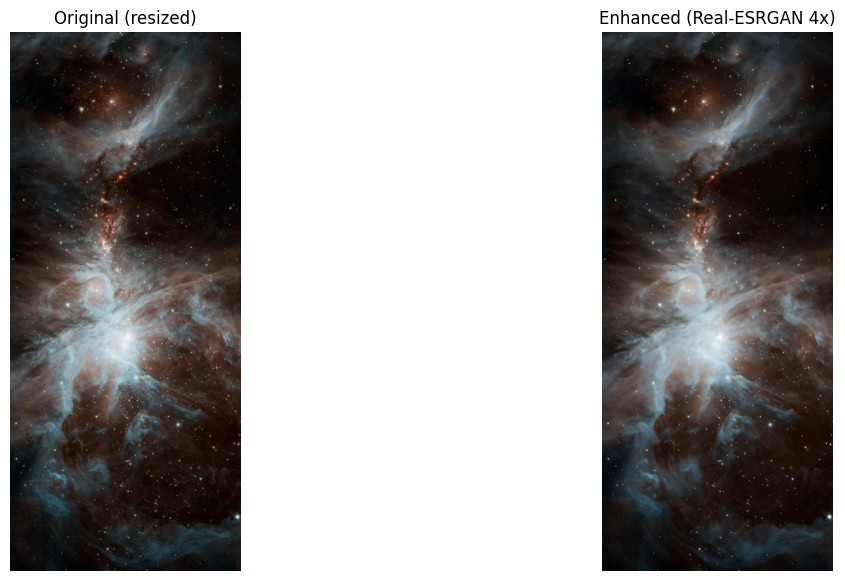

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(14,7))
axes[0].imshow(Image.open('resized_input.jpg'))
axes[0].set_title('Original (resized)')
axes[0].axis('off')
axes[1].imshow(Image.open('enhanced_moon.jpg'))
axes[1].set_title('Enhanced (Real-ESRGAN 4x)')
axes[1].axis('off')
plt.show()

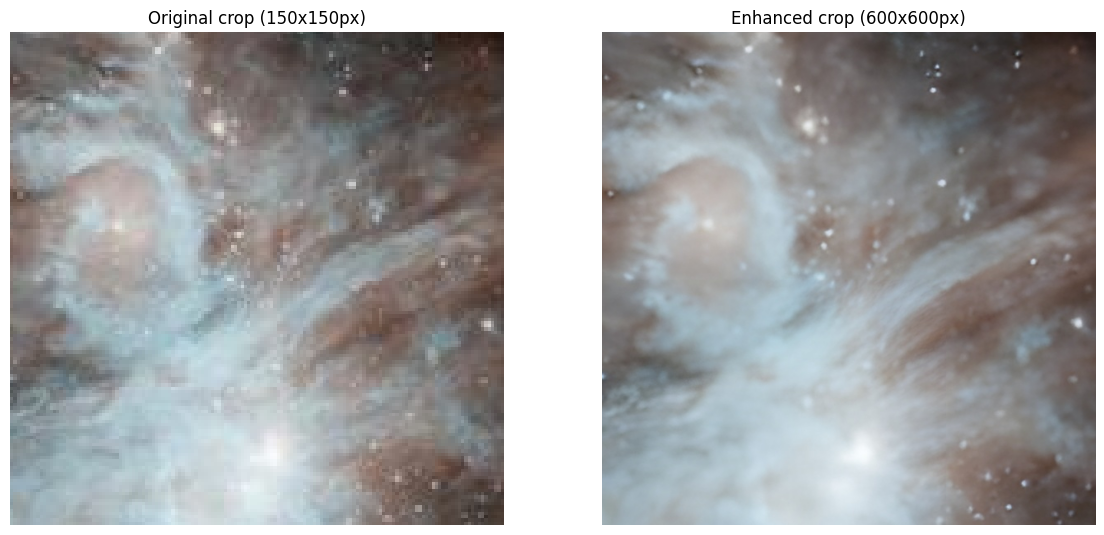

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

orig = Image.open('resized_input.jpg')
enhanced = Image.open('enhanced_moon.jpg')

# Crop the same relative region from both (e.g. center 150x150 px of original)
ow, oh = orig.size
ew, eh = enhanced.size

orig_crop = orig.crop((ow//2 - 75, oh//2 - 75, ow//2 + 75, oh//2 + 75))
# Enhanced image is 4x larger, so crop the equivalent 4x region
enhanced_crop = enhanced.crop((ew//2 - 300, eh//2 - 300, ew//2 + 300, eh//2 + 300))

fig, axes = plt.subplots(1, 2, figsize=(14,7))
axes[0].imshow(orig_crop)
axes[0].set_title(f'Original crop ({orig_crop.size[0]}x{orig_crop.size[1]}px)')
axes[0].axis('off')
axes[1].imshow(enhanced_crop)
axes[1].set_title(f'Enhanced crop ({enhanced_crop.size[0]}x{enhanced_crop.size[1]}px)')
axes[1].axis('off')
plt.show()

In [12]:
!wget https://images-assets.nasa.gov/image/PIA00405/PIA00405~orig.jpg -O sample_moon2.jpg

enhance_image('sample_moon2.jpg', 'enhanced_moon2.jpg')

--2026-08-12 08:46:26--  https://images-assets.nasa.gov/image/PIA00405/PIA00405~orig.jpg
Resolving images-assets.nasa.gov (images-assets.nasa.gov)... 99.84.215.24, 99.84.215.15, 99.84.215.94, ...
Connecting to images-assets.nasa.gov (images-assets.nasa.gov)|99.84.215.24|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 408513 (399K) [image/jpeg]
Saving to: ‘sample_moon2.jpg’

sample_moon2.jpg    100%[===================>] 398.94K  --.-KB/s    in 0.03s   

2026-08-12 08:46:26 (15.3 MB/s) - ‘sample_moon2.jpg’ saved [408513/408513]

Resized input from (1986, 1986) to (800, 800) to avoid memory crash
	Tile 1/16
	Tile 2/16
	Tile 3/16
	Tile 4/16
	Tile 5/16
	Tile 6/16
	Tile 7/16
	Tile 8/16
	Tile 9/16
	Tile 10/16
	Tile 11/16
	Tile 12/16
	Tile 13/16
	Tile 14/16
	Tile 15/16
	Tile 16/16
Saved enhanced image to enhanced_moon2.jpg


'enhanced_moon2.jpg'